# Longitudinal normative modelling

A normative model tells you where a single measurement sits relative to a reference population (a z-score). With **two or more visits per person**, we can go further and ask:

> Did this person change *more than expected* between visits?

This notebook shows the two scores PCNtoolkit provides for that question:

- **z-diff**
- **z-gain**

We use a cross-sectional dataset (`fcon1000`) to build the reference model, and a longitudinal dataset (`LNM_data`, two visits per subject) to score change over time.

In [16]:
# Pick up edits to local pcntoolkit code (e.g. velocity.py) without restarting
# the kernel. Restart the kernel if imports still look stale.
%load_ext autoreload
%autoreload 2

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

from pcntoolkit import (
    BLR,
    NormData,
    NormativeModel,
    ZDiffScore,
    ZGainScore,
 )
from pcntoolkit.math_functions.basis_function import (
    BsplineBasisFunction,
 )
from pcntoolkit.util.plotter import plot_centiles_advanced


def find_data_dir():
    """Locate the example-data folder by searching upward."""
    # Check the current folder and each parent folder in turn.
    for base in [Path.cwd(), *Path.cwd().parents]:
        candidate = base / "pcntoolkit_resources" / "data"
        # Stop once both files needed by this notebook are found.
        if (
            (candidate / "fcon1000.csv").exists()
            and (candidate / "LNM_data.csv").exists()
        ):
            return candidate
    raise FileNotFoundError(
        "Could not find pcntoolkit_resources/data with "
        "fcon1000.csv and LNM_data.csv"
    )


data_dir = find_data_dir()


def tidy_region_names(df):
    """Use one consistent naming for cortical-thickness columns. Makes sure
    that both datasets have the same column names for the same regions."""
    return df.rename(
        columns={
            c: c.replace("&", "_and_").replace(
                "_thickness", ""
            )
            for c in df.columns
        }
    )


# Choose two cortical-thickness regions
response_vars = ["rh_S_front_sup", "rh_G_front_middle"] # I select these regions as they were found significant in this notebook: https://github.com/predictive-clinical-neuroscience/pu25_code/blob/main/notebooks/secondary_workflows/longitudinal_modelling.ipynb

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Build the reference model

We fit a normative model of cortical thickness against age on the cross-sectional reference data.

In [17]:
# Load the cross-sectional reference cohort used to fit the model.
reference_df = tidy_region_names(pd.read_csv(data_dir / "fcon1000.csv"))

reference_data = NormData.from_dataframe(
    name="reference",
    dataframe=reference_df,
    covariates=["age"],
    batch_effects=["site", "sex"],
    response_vars=response_vars,
    subject_ids="sub_id",
)

fcon1000_model = NormativeModel(
    BLR(
        basis_function_mean=BsplineBasisFunction(degree=3, nknots=5),
        warp_name="warpsinharcsinh",
    ),
    inscaler="standardize",
    outscaler="standardize",
    savemodel=False,
    saveresults=False,
)

fcon1000_model.fit(reference_data);

Process: 1220 - 2026-07-08 00:59:14 - Dataset "reference" created.
    - 1078 observations
    - 1078 unique subjects
    - 1 covariates
    - 2 response variables
    - 2 batch effects:
    	site (23)
	sex (2)
    
Process: 1220 - 2026-07-08 00:59:14 - Fitting models on 2 response variables.
Process: 1220 - 2026-07-08 00:59:14 - Fitting model for rh_S_front_sup.
Process: 1220 - 2026-07-08 00:59:15 - Fitting model for rh_G_front_middle.
Process: 1220 - 2026-07-08 00:59:19 - Making predictions on 2 response variables.
Process: 1220 - 2026-07-08 00:59:19 - Computing z-scores for 2 response variables.
Process: 1220 - 2026-07-08 00:59:19 - Computing z-scores for rh_S_front_sup.
Process: 1220 - 2026-07-08 00:59:19 - Computing z-scores for rh_G_front_middle.
Process: 1220 - 2026-07-08 00:59:19 - Computing centiles for 2 response variables.
Process: 1220 - 2026-07-08 00:59:19 - Computing centiles for rh_S_front_sup.
Process: 1220 - 2026-07-08 00:59:19 - Computing centiles for rh_G_front_middl

### Visualize the reference data

Before modelling it helps to look at the cross-sectional reference cohort: how many subjects each site contributes (split by sex), and how cortical thickness varies with age across sites.

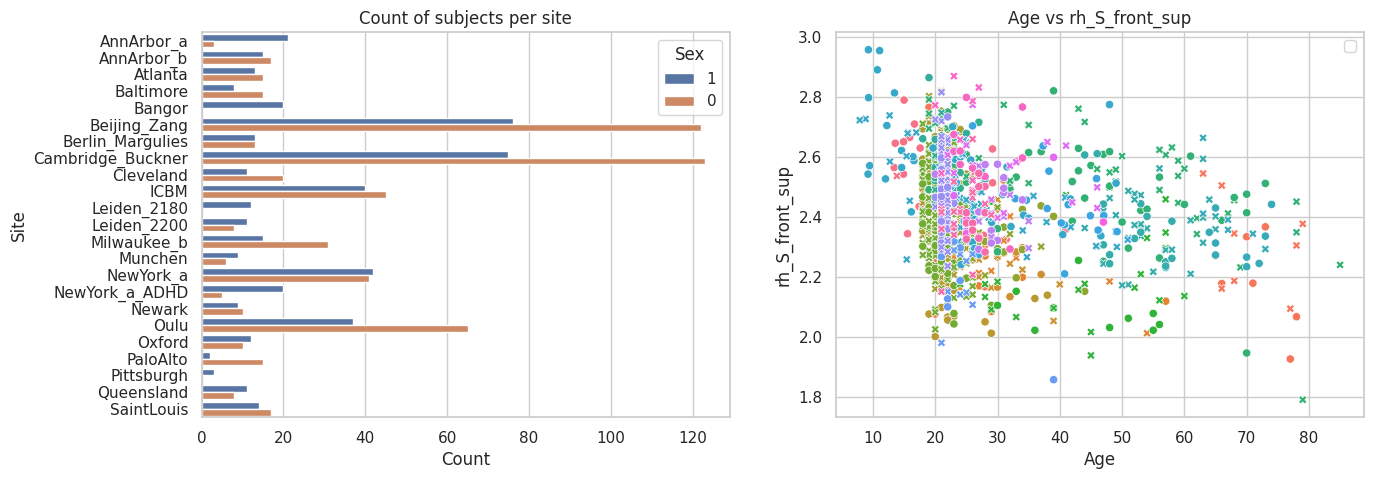

In [18]:
# Pick the region to plot and pull the data into a flat dataframe.
feature_to_plot = response_vars[0]
df = reference_data.to_dataframe()

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Left: how many subjects each site contributes, split by sex.
sns.countplot(
    data=df,
    y=("batch_effects", "site"),
    hue=("batch_effects", "sex"),
    ax=ax[0],
    orient="h",
)
ax[0].legend(title="Sex")
ax[0].set_title("Count of subjects per site")
ax[0].set_xlabel("Count")
ax[0].set_ylabel("Site")

# Right: thickness against age, coloured by site and styled by sex.
sns.scatterplot(
    data=df,
    x=("X", "age"),
    y=("Y", feature_to_plot),
    hue=("batch_effects", "site"),
    style=("batch_effects", "sex"),
    ax=ax[1],
)
# Hide the very long site legend to keep the panel readable.
ax[1].legend([], [])
ax[1].set_title(f"Age vs {feature_to_plot}")
ax[1].set_xlabel("Age")
ax[1].set_ylabel(feature_to_plot)

plt.show()

## 2a. Load the longitudinal data

Each subject in `LNM_data` has two visits. We load it and line up its column names with the reference data.

In [19]:
# Load the longitudinal data
longitudinal_df = tidy_region_names(pd.read_csv(data_dir / "LNM_data.csv"))

# Split the longitudinal data into two groups: controls and patients.
control_df = longitudinal_df[longitudinal_df["group"] == "control"]
control_data = NormData.from_dataframe(
    name="control",
    dataframe=control_df,
    covariates=["age"],
    batch_effects=["site", "sex"],
    response_vars=response_vars,
    subject_ids="sub_id",
)

patient_df = longitudinal_df[longitudinal_df["group"] == "patient"]
patient_data = NormData.from_dataframe(
    name="patient",
    dataframe=patient_df,
    covariates=["age"],
    batch_effects=["site", "sex"],
    response_vars=response_vars,
    subject_ids="sub_id",
)

Process: 1220 - 2026-07-08 00:59:23 - Dataset "control" created.
    - 134 observations
    - 67 unique subjects
    - 1 covariates
    - 2 response variables
    - 2 batch effects:
    	site (1)
	sex (2)
    
Process: 1220 - 2026-07-08 00:59:23 - Dataset "patient" created.
    - 196 observations
    - 98 unique subjects
    - 1 covariates
    - 2 response variables
    - 2 batch effects:
    	site (1)
	sex (2)
    


### Visualize the longitudinal data

Each subject has **two visits**, so we can draw a line per subject connecting their two timepoints. We colour each point by visit number and use one panel per group (controls vs patients). This makes the within-subject change over time visible at a glance.

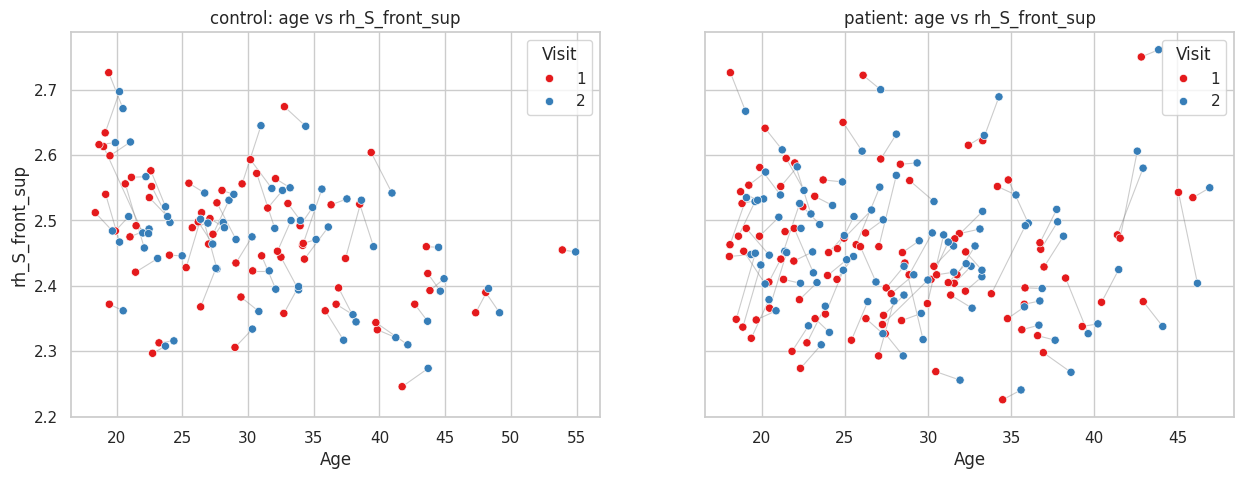

In [20]:
# Region to plot and the two groups, each in its own panel.
feature_to_plot = response_vars[0]
groups = {"control": control_df, "patient": patient_df}

fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

# One panel per group: controls on the left, patients on the right.
for axis, (group_name, group_df) in zip(ax, groups.items()):
    # Connect each subject's two visits with a thin grey line so the
    # within-subject trajectory over time is visible.
    for _, subject_rows in group_df.groupby("sub_id"):
        ordered = subject_rows.sort_values("visit")
        axis.plot(
            ordered["age"],
            ordered[feature_to_plot],
            color="grey",
            alpha=0.4,
            lw=0.8,
            zorder=1,
        )

    # Overlay the visits as points coloured by visit number.
    sns.scatterplot(
        data=group_df,
        x="age",
        y=feature_to_plot,
        hue="visit",
        palette="Set1",
        s=35,
        ax=axis,
        zorder=2,
    )
    axis.legend(title="Visit")
    axis.set_title(f"{group_name}: age vs {feature_to_plot}")
    axis.set_xlabel("Age")
    axis.set_ylabel(feature_to_plot)

plt.show()

Patients seems to have bigger changes from visit 1 to visit 2 than the controls

## 2b. Transfer and predict

The LNM and fcon1000 data have different sites. For this reason we need to first transfer the fcon1000 model to the LNM data and then do our predictions.

In [21]:
# Keep 20% as the adaptation set. We will use this to transfer the fcon1000 model to the LNM data.
control_adapt, control_test = control_data.train_test_split(splits=[0.2, 0.8])

# transfer
lnm_model = fcon1000_model.transfer(control_adapt);

# predict
lnm_model.predict(control_test);
lnm_model.predict(patient_data);

Process: 1220 - 2026-07-08 00:59:27 - Transferring models on 2 response variables.
Process: 1220 - 2026-07-08 00:59:27 - Transferring model for rh_S_front_sup.
Process: 1220 - 2026-07-08 00:59:27 - Transferring model for rh_G_front_middle.
Process: 1220 - 2026-07-08 00:59:27 - Saving model to:
	/root/.pcntoolkit/saves_transfer.
Process: 1220 - 2026-07-08 00:59:27 - Making predictions on 2 response variables.
Process: 1220 - 2026-07-08 00:59:27 - Computing z-scores for 2 response variables.
Process: 1220 - 2026-07-08 00:59:27 - Computing z-scores for rh_S_front_sup.
Process: 1220 - 2026-07-08 00:59:27 - Computing z-scores for rh_G_front_middle.
Process: 1220 - 2026-07-08 00:59:27 - Computing centiles for 2 response variables.
Process: 1220 - 2026-07-08 00:59:27 - Computing centiles for rh_S_front_sup.
Process: 1220 - 2026-07-08 00:59:27 - Computing centiles for rh_G_front_middle.
Process: 1220 - 2026-07-08 00:59:27 - Computing log-probabilities for 2 response variables.
Process: 1220 - 

## 3. z-diff
Values near 0 are typical; large positive or negative values indicate unusual change.

In [22]:
# we use as reference daa the control test data
zdiff = ZDiffScore(
    normative_model=lnm_model,
    reference_data=control_test,
    subject_id_col="sub_id",
)

# we use as score data the patient data 
zdiff_scores = zdiff.score(
    score_data = patient_data,
    subject_id_col="sub_id",
    timepoint_col="visit",
)

# Show the first few subject-level z-diff scores.
zdiff_scores.to_dataframe(name="z_diff").unstack("response_vars").head()

z_diff                  
response_vars rh_S_front_sup rh_G_front_middle
subjects                                      
P000               -0.322964         -0.565736
P001               -2.297495         -2.848406
P002               -0.516952         -0.229765
P003                0.494147          1.133814
P004                0.192776         -0.492138

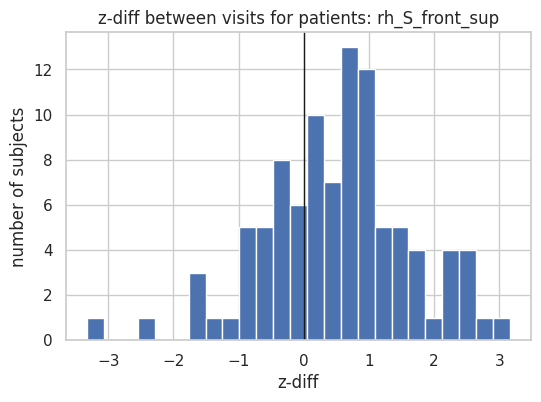

In [23]:
# Pick one region
region = response_vars[0]

# Plot the distribution of z-diff values across subjects.
plt.figure(figsize=(6, 4))
plt.hist(
    zdiff_scores.sel(response_vars=region).values,
    bins=25,
    color="#4c72b0",
    edgecolor="white",
)

# Mark zero, which corresponds to typical change.
plt.axvline(0, color="k", lw=1)
plt.xlabel("z-diff")
plt.ylabel("number of subjects")
plt.title(f"z-diff between visits for patients: {region}")
plt.show()

## 4a. z-gain

`ZGainScore` asks whether a subject's z-score at the later visit is surprising given their earlier visit. It relies on how strongly z-scores are correlated across ages, which it estimates as a **correlation matrix**.

After you create a `ZGainScore`, several results are **cached on the object** so you can retrieve them later without keeping every return value:

| Attribute | Set by | Contents |
|-----------|--------|----------|
| `zgain.correlation_matrix` | first call to `score()` or `get_thrivelines()` | age-to-age z-score correlation matrix `R` |
| `zgain.zgain` | `score()` | subject-level z-gain scores (same array as the return value) |
| `zgain.thrivelines` | `get_thrivelines()` | `xr.Dataset` with `Z`, `X`, and `Y` thriveline grids |

All three start as `None` and are filled the first time the corresponding method runs.

In [24]:
# Reference cohort: control test data (longitudinal, with predicted z-scores).
zgain = ZGainScore(
    normative_model=lnm_model,
    reference_data=control_test,
    subject_id_col="sub_id",
    bandwidth=3,  # correlation estimated within a 3-year age window
    covariate="age",
)

# Score patient data. The array is returned *and* stored on the object.
zgain_scores = zgain.score(
    score_data=patient_data,
    subject_id_col="sub_id",
    timepoint_col="visit",
)

# Same result without keeping the return value:
assert zgain.zgain is zgain_scores

# The correlation matrix R is computed on first use and then reused.
assert zgain.correlation_matrix is not None

# Show the first few subject-level z-gain scores.
zgain_scores.to_dataframe(name="z_gain").unstack("response_vars").head()

z_gain                  
response_vars rh_S_front_sup rh_G_front_middle
subjects                                      
P000               -1.218579         -1.453539
P001               -7.754113         -6.219977
P002               -1.012166         -0.517759
P003                1.568706          2.982843
P004                0.860851         -0.970241

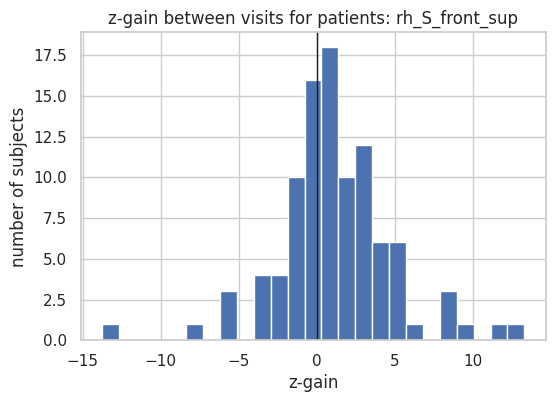

In [25]:
# Pick one region
region = response_vars[0]

# Plot the distribution of zgain values across subjects.
plt.figure(figsize=(6, 4))
plt.hist(
    zgain_scores.sel(response_vars=region).values,
    bins=25,
    color="#4c72b0",
    edgecolor="white",
)

# Mark zero, which corresponds to typical change.
plt.axvline(0, color="k", lw=1)
plt.xlabel("z-gain")
plt.ylabel("number of subjects")
plt.title(f"z-gain between visits for patients: {region}")
plt.show()

## 4b. Correlation matrix

`score()` computes and caches the correlation matrix on `zgain.correlation_matrix`. Later calls (`score()`, `get_thrivelines()`) reuse it instead of recomputing.

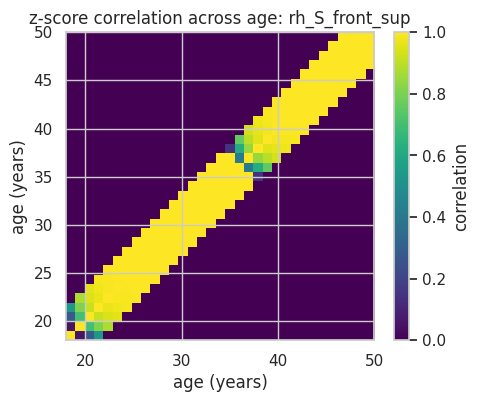

In [26]:
# The learned correlation matrix is stored after z-gain is computed.
R = zgain.correlation_matrix.sel(response_vars=region)

# Restrict both axes to the cohort age range (18-50). Outside this
# range the matrix is extrapolated and not trustworthy, so we hide it.
age_lo, age_hi = 18, 50
R = R.sel(age_1=slice(age_lo, age_hi), age_2=slice(age_lo, age_hi))

# Display the age-to-age z-score correlation matrix as a heatmap.
plt.figure(figsize=(5, 4))
plt.imshow(
    R.values,
    origin="lower",
    extent=[age_lo, age_hi, age_lo, age_hi],
    vmin=0,
    vmax=1,
    cmap="viridis",
)
plt.colorbar(label="correlation")
plt.xlabel("age (years)")
plt.ylabel("age (years)")
plt.title(f"z-score correlation across age: {region}")
plt.show()

## 4c. Thrivelines

Thrivelines show how a z-score is expected to evolve over one covariate step (default: one year), given the age-to-age correlations estimated from the reference cohort.

`zgain.get_thrivelines()` propagates anchor trajectories and maps them to the response scale. The result is stored on `zgain.thrivelines`:

| Variable | Contents |
|----------|----------|
| `thrivelines.Z` | propagated z-scores along each segment |
| `thrivelines.X` | covariate coordinates (age) |
| `thrivelines.Y` | predicted response values from the normative model |


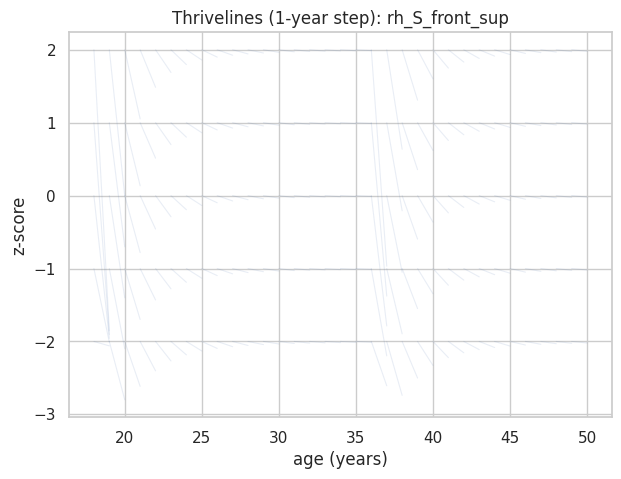

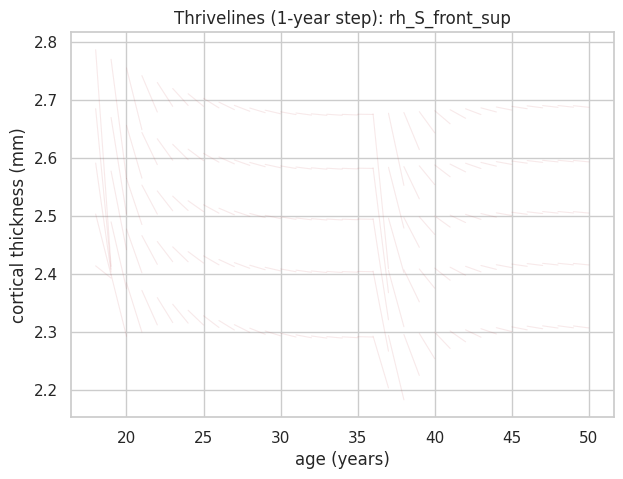

In [27]:
# Grid overlay: anchor age × starting z-score (omit data= for this mode).
thrivelines = zgain.get_thrivelines(
    z_anchor_start=-2,
    z_anchor_end=3,
    covariate_range=(18, 50),
)

assert zgain.thrivelines is thrivelines

z_lines = thrivelines.Z.sel(response_vars=region, drop=True)
x_lines = thrivelines.X.sel(response_vars=region, drop=True)
y_lines = thrivelines.Y.sel(response_vars=region, drop=True)

plt.figure(figsize=(7, 5))
for seg in range(z_lines.sizes["segment"]):
    plt.plot(
        x_lines.isel(segment=seg).values,
        z_lines.isel(segment=seg).values,
        color="#4c72b0",
        alpha=0.12,
        lw=0.8,
    )
plt.xlabel("age (years)")
plt.ylabel("z-score")
plt.title(f"Thrivelines (1-year step): {region}")
plt.show()

plt.figure(figsize=(7, 5))
for seg in range(y_lines.sizes["segment"]):
    plt.plot(
        x_lines.isel(segment=seg).values,
        y_lines.isel(segment=seg).values,
        color="#c44e52",
        alpha=0.12,
        lw=0.8,
    )
plt.xlabel("age (years)")
plt.ylabel("cortical thickness (mm)")
plt.title(f"Thrivelines (1-year step): {region}")
plt.show()


Note: we have only a few control subjects that the correlation matrix is computed from (if i counted right there are 67 subjects in the control_test). Each off-diagonal cell `(age_1, age_2)` needs at least 4 control subjects at both ages; otherwise, the value is estimated through regression and might not be trustworthy (see this dark blue -> yellow -> dakr blue -> yellow pattern as we go from young to old ages in the correlation matrix). 

I think we would need a bigger LNM dataset to compute the correlation matrix (TODO: discuss with Andre about that)

## 5. Are the results as expected?

We expect z-diff and z-gain to broadly agree on who shows unusual change, since both measure the same thing on this two-visit data.

z-diff: mean = 0.50, sd = 1.13
z-gain: mean = 1.17, sd = 3.71
agreement (same direction): 93%


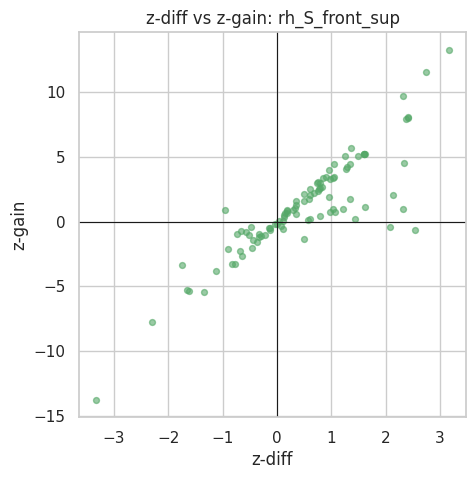

In [28]:
# Read the two longitudinal scores for one region.
zd = zdiff_scores.sel(response_vars=region).values
zg = zgain_scores.sel(response_vars=region).values


# Summarise the location and spread of the two score distributions.
print(f"z-diff: mean = {zd.mean():.2f}, sd = {zd.std():.2f}")
print(f"z-gain: mean = {zg.mean():.2f}, sd = {zg.std():.2f}")
print(
    "agreement (same direction): "
    f"{np.mean(np.sign(zd) == np.sign(zg)):.0%}"
)

# Plot the subject-level agreement between z-diff and z-gain.
plt.figure(figsize=(5, 5))
plt.scatter(zd, zg, s=18, alpha=0.6, color="#55a868")
plt.axhline(0, color="k", lw=0.8)
plt.axvline(0, color="k", lw=0.8)
plt.xlabel("z-diff")
plt.ylabel("z-gain")
plt.title(f"z-diff vs z-gain: {region}")
plt.show()

## Choosing between z-diff and z-gain
 
| You have…                              | Use          |
|----------------------------------------|--------------|
| Two timepoints, BLR or wBLR model      | `ZDiffScore` or `ZGainScore`|
| Want thrive lines and/or conditional forecasting     | `ZGainScore` |
| Three or more timepoints               | `ZGainScore`  |
 

A large positive or negative score flags a subject whose change over time is unusual compared with the reference population -- could be a useful metric to find atypical trajectories in clinical populations.

## 6. Plot thrivelines on centile curves

`plot_centiles_advanced` overlays pre-computed thrivelines on the normative centile plot. Pass the `thrivelines` dataset from `zgain.get_thrivelines()` — the plotter reads `thrivelines.X` and `thrivelines.Y` and does not recompute them.

To start each line on a centile curve, set `z_anchors=norm.ppf(centiles)` when calling `get_thrivelines()`.


Process: 1220 - 2026-07-08 01:01:32 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	site (1)
	sex (1)
    
Process: 1220 - 2026-07-08 01:01:32 - Computing centiles for 1 response variables.
Process: 1220 - 2026-07-08 01:01:32 - Computing centiles for rh_S_front_sup.


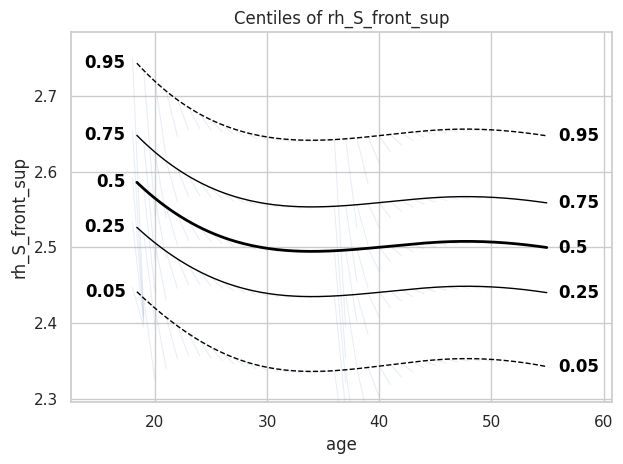

[<Figure size 640x480 with 1 Axes>]

In [30]:
centiles = [0.05, 0.25, 0.5, 0.75, 0.95]

# Recompute thrivelines so anchors match the plotted centile curves.
plot_thrivelines = zgain.get_thrivelines(
    covariate_range=(18, 50),
    z_anchors=stats.norm.ppf(centiles),
)

plot_centiles_advanced(
    lnm_model,
    centiles=centiles,
    response_vars=[region],
    covariate="age",
    thrivelines=plot_thrivelines,
    show_legend=False,
)